# Lab 5 — Multi-Agent Deep Reinforcement Learning

**TDDE78 — Deep Reinforcement Learning**  
Linköping University, Spring 2026

---

## Overview

This lab extends deep RL to settings with **multiple interacting agents**. You will implement two CTDE (Centralized Training, Decentralized Execution) algorithms:

| Algorithm | Type | Critic input | Policy type |
|-----------|------|--------------|-------------|
| **MAPPO** | On-policy | Joint observations V(o₁…oₙ) | Shared actor (parameter sharing) |
| **MADDPG** | Off-policy | Joint obs + joint actions Q_i(o,a) | Per-agent actors (independent) |

Both follow the CTDE principle:
- **Decentralized execution**: each agent acts from its *own local observation* only
- **Centralized training**: critics see *all agents' observations (and actions)* for better credit assignment

### What you implement 
- `CentralizedCritic` — joint V(o₁, o₂, …, oₙ) for MAPPO  →  `networks.py`
- `MAPPOAgent.select_actions()` and `MAPPOAgent.update()`  →  this notebook
- `MADDPGAgents.select_actions()` and `MADDPGAgents.update()`  →  this notebook

### What is provided (do NOT re-implement)
- `DiscreteActor` from Lab 2 (shared across agents, MAPPO)
- `MADDPGActor` / `MADDPGCritic` — MADDPG network architectures
- `compute_gae`, `MultiAgentReplayBuffer`, plotting utilities
- `train_mappo` and `train_maddpg` training loops

### Environment
**simple_spread_v3** (PettingZoo) — 3 cooperative agents must spread to cover 3 landmarks.

| Property | Value |
|----------|-------|
| Agents | 3 (cooperative) |
| Obs dim | 18 per agent |
| Actions | 5 discrete |
| Episode length | 25 steps |

### Reference
Lowe et al., *"Multi-Agent Actor-Critic for Mixed Cooperative-Competitive Environments"*, NeurIPS 2017.

In [2]:
# Install PettingZoo if not already available
import subprocess, sys
try:
    import pettingzoo
except ImportError:
    print("Installing pettingzoo...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pettingzoo[mpe]", "-q"])

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os

# --- Resolve notebook directory and experiments output path ---
_here   = globals().get('__vsc_ipynb_file__', os.path.abspath(''))
_nb_dir = os.path.dirname(_here) if os.path.isfile(_here) else _here
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

EXPERIMENTS_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'experiments'))
print(f'Experiments directory: {EXPERIMENTS_DIR}')

from networks import (
    DiscreteActor, CentralizedCritic,
    MADDPGActor, MADDPGCritic, layer_init,
)
from utils import (
    compute_gae, MultiAgentReplayBuffer,
    plot_mappo_results, plot_maddpg_results, plot_comparison,
    _save_plot, smooth,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Environment constants
N_AGENTS   = 3
OBS_DIM    = 18    # simple_spread_v3 with N=3
ACTION_DIM = 5

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Setup complete!")

Experiments directory: /home/arviv790/Code/LiU/tdde78/labs/lab5_multi_agent/experiments
Device: cuda
Setup complete!


---

## A.0 — Explore the Environment

**simple_spread_v3** (PettingZoo MPE) — 3 cooperative agents must each reach one of 3 landmarks.

| Property | Value |
|----------|-------|
| Agents | 3 (`agent_0`, `agent_1`, `agent_2`) |
| Observation | 18-dim per agent (own vel + pos, landmark positions, other agents' positions) |
| Actions | 5 discrete (no-op, left, right, up, down) |
| Reward | Shared: −Σ min‖agent − landmark‖ per step |
| Episode length | 25 steps |

The task is **cooperative**: agents are rewarded as a team for collectively covering all landmarks.


In [3]:
from pettingzoo.mpe import simple_spread_v3

env = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)
obs_dict, _ = env.reset(seed=42)

print(f"Agents       : {env.agents}")
print(f"Obs space    : {env.observation_space('agent_0')}  → dim {OBS_DIM}")
print(f"Action space : {env.action_space('agent_0')}  → {ACTION_DIM} discrete actions")
print(f"  0=no-op  1=left  2=right  3=up  4=down")

# Random rollout to see baseline performance
ep_reward = 0.0
for _ in range(25):
    actions = {a: env.action_space(a).sample() for a in env.agents}
    _, rewards, _, _, _ = env.step(actions)
    ep_reward += sum(rewards.values())
print(f"\nRandom agent — episode reward: {ep_reward:.1f}  (good policy ≈ −30)")
env.close()

/tmp/ipykernel_617237/1787415979.py:1: DeprecationWarning: The environment `pettingzoo.mpe` has been moved to `mpe2` and will be removed in a future release.Please update your imports.
  from pettingzoo.mpe import simple_spread_v3
/home/arviv790/Code/LiU/tdde78/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Agents       : ['agent_0', 'agent_1', 'agent_2']
Obs space    : Box(-inf, inf, (18,), float32)  → dim 18
Action space : Discrete(5)  → 5 discrete actions
  0=no-op  1=left  2=right  3=up  4=down

Random agent — episode reward: -78.1  (good policy ≈ −30)


## Part A: Implementation

### A.1 — MAPPO
**Step 1:** Implement `CentralizedCritic` in `networks.py`  
**Step 2:** Implement `MAPPOAgent.select_actions()` and `MAPPOAgent.update()` below

### A.2 — MADDPG
**Step 3:** Implement `MADDPGAgents.select_actions()` and `MADDPGAgents.update()` below  
(Networks `MADDPGActor` and `MADDPGCritic` are provided — no changes to `networks.py`)

In [ ]:
class MAPPOAgent:
    """
    Multi-Agent PPO with parameter sharing and centralized critic (CTDE).

    Architecture:
    - Shared DiscreteActor: one set of weights used by ALL agents
    - CentralizedCritic: sees joint observations (all agents concatenated)

    Training:
    - Collect rollout_episodes full-episode rollouts (concatenated along time)
    - Normalize rewards globally across the whole batch before computing GAE
    - n_epochs PPO updates on shared actor and centralized critic
    """

    def __init__(
        self,
        obs_dim: int,
        action_dim: int,
        n_agents: int,
        critic=None,
        lr: float = 3e-4,
        gamma: float = 0.99,
        gae_lambda: float = 0.95,
        clip_eps: float = 0.2,
        vf_coef: float = 0.5,
        ent_coef: float = 0.001,
        n_epochs: int = 4,
        batch_size: int = 64,
        max_grad_norm: float = 0.5,
    ):
        self.obs_dim       = obs_dim
        self.action_dim    = action_dim
        self.n_agents      = n_agents
        self.gamma         = gamma
        self.gae_lambda    = gae_lambda
        self.clip_eps      = clip_eps
        self.vf_coef       = vf_coef
        self.ent_coef      = ent_coef
        self.n_epochs      = n_epochs
        self.batch_size    = batch_size
        self.max_grad_norm = max_grad_norm

        self.actor  = DiscreteActor(obs_dim, action_dim).to(device)
        self.critic = (critic if critic is not None
                       else CentralizedCritic(obs_dim, n_agents)).to(device)

        self.optimizer = torch.optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()), lr=lr
        )
        

    @torch.no_grad()
    def select_actions(self, obs_dict, agent_list):
        """
        Select actions for all agents (DECENTRALIZED execution).
        Each agent runs the SHARED actor on its OWN observation only.

        Also computes the centralized value estimate for this step
        (used for GAE during training).

        Args:
            obs_dict   (dict): {agent_id: np.array(obs_dim)}
            agent_list (list): ordered list of agent ids

        Returns:
            actions   (dict): {agent_id: int}
            log_probs (dict): {agent_id: float}
            value     (float): centralized V(joint_obs)
        """
        # TODO: For each agent run the shared actor on its own observation to
        # get an action and log-prob. Build the joint observation (all agents
        # concatenated) and pass it to the centralized critic to get the value.
        
        #Loop that gets all actions and log_probs and converts them to dicts
        actions, log_probs = {}, {}
        for agent in agent_list:
            obs_tensor = torch.tensor(obs_dict[agent], dtype=torch.float32).unsqueeze(0).to(device) #unsqueeze(0) to add batch dim
            action, log_prob, _ = self.actor.get_action(obs_tensor)
            actions[agent] = action.item()
            log_probs[agent] = log_prob.item()
        
        #Concatenated joint_obs passed to centralized critic
        joint_obs = torch.cat([torch.tensor(obs_dict[agent], dtype=torch.float32) for agent in agent_list]).unsqueeze(0).to(device) #unsqueeze(0) to add batch dim
        value = self.critic(joint_obs).item()
        
        return actions, log_probs, value
     

    def update(self, obs_arr, actions_arr, rewards_arr, dones_arr,
               log_probs_arr, values_arr, last_value):
        """
        PPO update over a concatenated multi-episode rollout.

        Args:
            obs_arr      (np.ndarray): (T, n_agents, obs_dim)
            actions_arr  (np.ndarray): (T, n_agents)  — integer actions
            rewards_arr  (np.ndarray): (T, n_agents)  — per-agent rewards
            dones_arr    (np.ndarray): (T,)            — episode-end flags
            log_probs_arr(np.ndarray): (T, n_agents)  — log π(a|o) at collection
            values_arr   (np.ndarray): (T,)            — centralized V(s) at collection
            last_value   (float):      V(s_T) bootstrap

        Returns:
            (policy_loss, value_loss) averaged over update steps
        """
        # TODO:
        # 1. Normalize rewards globally (agents share reward in simple_spread).
        rewards_arr = (rewards_arr - rewards_arr.mean()) / (rewards_arr.std() + 1e-8)
        
        # 2. Compute GAE advantages and returns per agent using compute_gae,
        #    then normalize advantages across all agents.
        T = obs_arr.shape[0]
        advantages_arr = np.zeros((T, self.n_agents), dtype=np.float32)
        returns_arr = np.zeros((T, self.n_agents), dtype=np.float32)
        
        for i in range(self.n_agents):
            advantages_arr[:, i], returns_arr[:, i] = compute_gae(rewards_arr[:, i], values_arr, dones_arr, last_value, self.gamma, self.gae_lambda)

        advantages_arr = (advantages_arr - advantages_arr.mean()) / (advantages_arr.std() + 1e-8)
        
        # 3. Flatten observations and actions across agents for the actor;
        #    build joint observations for the centralized critic.
        #Cast to tensors because tensors expected below
        obs_t = torch.tensor(obs_arr, dtype=torch.float32).to(device)
        actions_t = torch.tensor(actions_arr, dtype=torch.long).to(device)
        log_probs_t = torch.tensor(log_probs_arr, dtype=torch.float32).to(device)
        advantages_t = torch.tensor(advantages_arr, dtype=torch.float32).to(device)
        
        #Joint observations and mean returns for critic stuff
        obs_critic = np.reshape(obs_arr, (T, self.n_agents * self.obs_dim))
        joint_obs_t = torch.tensor(obs_critic, dtype=torch.float32).to(device)
        returns_t = torch.tensor(returns_arr.mean(axis=1), dtype=torch.float32).to(device) #(T,)
        
        # 4. Run n_epochs of mini-batch PPO updates:
        #    - Actor: clipped surrogate loss minus entropy bonus.
        #    - Critic: MSE on mean returns across agents.
        #    Clip gradients before each optimizer step.
        total_policy_loss = 0.0
        total_value_loss = 0.0
        n_updates = 0
        for _ in range(self.n_epochs):
            for start in range(0, T, self.batch_size):
                indexes = slice(start, start + self.batch_size)
                
                #Reshape stuff for actor
                obs_batch = obs_t[indexes].reshape(-1, self.obs_dim) #(batch*n_agents, obs_dim)
                actions_batch = actions_t[indexes].reshape(-1)       #(batch*n_agents,)
                log_probs_batch = log_probs_t[indexes].reshape(-1)   #(batch*n_agents,)
                advantages_batch = advantages_t[indexes].reshape(-1) #(batch*n_agents,)
                
                _, new_log_probs, entropy = self.actor.get_action(obs_batch, actions_batch)
                prob_ratio = (new_log_probs - log_probs_batch).exp() #Formula from lab2, minus instead of division because we're in log space
                
                #Actor: Using clipped surrogate objective formula
                surrogate1 = prob_ratio * advantages_batch
                surrogate2 = torch.clip(prob_ratio, 1 - self.clip_eps, 1 + self.clip_eps) * advantages_batch
                policy_loss = -torch.min(surrogate1, surrogate2).mean() - self.ent_coef * entropy.mean() # -L^CLIP - C_H * H
                
                #Critic: MSE on mean returns across agents
                value_pred = self.critic(joint_obs_t[indexes]).squeeze(-1)
                value_loss = self.vf_coef * F.mse_loss(value_pred, returns_t[indexes])
                
                #Classic gradient descent update, with gradient clipping
                self.optimizer.zero_grad()
                (policy_loss + value_loss).backward()
                nn.utils.clip_grad_norm_(list(self.actor.parameters()) + list(self.critic.parameters()), self.max_grad_norm)
                self.optimizer.step()
                
                total_policy_loss += policy_loss.item()
                total_value_loss += value_loss.item()
                n_updates += 1
                
        return (total_policy_loss / n_updates), (total_value_loss / n_updates)

In [10]:
def train_mappo(env, agent, n_episodes=5000, rollout_episodes=10, print_every=500):
    """
    Train MAPPOAgent on a PettingZoo parallel environment.

    Fully provided — do NOT modify.

    Collects `rollout_episodes` full episodes before each PPO update,
    concatenated along the time axis. This gives larger, less noisy batches
    — key for stable MAPPO learning (mirrors epymarl's batch_size=10 episodes).

    Episode boundaries are preserved via the done flags so GAE does not
    bleed across episodes.

    Args:
        env              : PettingZoo parallel environment
        agent            : MAPPOAgent
        n_episodes       : Total number of training episodes
        rollout_episodes : Episodes collected per PPO update
        print_every      : Logging interval (episodes)

    Returns:
        results (dict): 'episode_rewards', 'policy_losses', 'value_losses'
    """
    results = {'episode_rewards': [], 'policy_losses': [], 'value_losses': []}
    episode = 0

    while episode < n_episodes:
        # --- Collect rollout_episodes episodes ---
        batch_obs, batch_actions, batch_rewards = [], [], []
        batch_dones, batch_log_probs, batch_values = [], [], []

        for _ in range(min(rollout_episodes, n_episodes - episode)):
            obs_dict, _ = env.reset()
            agent_list  = list(obs_dict.keys())

            ep_obs, ep_actions, ep_rewards   = [], [], []
            ep_dones, ep_log_probs, ep_values = [], [], []
            ep_total_reward = 0.0

            while env.agents:
                actions, log_probs, value = agent.select_actions(obs_dict, agent_list)

                obs_arr = np.array([obs_dict[a] for a in agent_list])
                ep_obs.append(obs_arr)
                ep_actions.append([actions[a]    for a in agent_list])
                ep_log_probs.append([log_probs[a] for a in agent_list])
                ep_values.append(value)

                next_obs, rewards, terminations, truncations, _ = env.step(actions)
                dones = {a: terminations.get(a, False) or truncations.get(a, False)
                         for a in agent_list}

                ep_rewards.append([rewards.get(a, 0.0) for a in agent_list])
                ep_dones.append(float(any(dones.values())))
                ep_total_reward += sum(rewards.get(a, 0.0) for a in agent_list)
                obs_dict = next_obs

            results['episode_rewards'].append(ep_total_reward)
            episode += 1

            batch_obs.append(np.array(ep_obs,        dtype=np.float32))
            batch_actions.append(np.array(ep_actions,   dtype=np.int64))
            batch_rewards.append(np.array(ep_rewards,   dtype=np.float32))
            batch_dones.append(np.array(ep_dones,     dtype=np.float32))
            batch_log_probs.append(np.array(ep_log_probs, dtype=np.float32))
            batch_values.append(np.array(ep_values,    dtype=np.float32))

        # --- Concatenate episodes along time axis and update once ---
        p_loss, v_loss = agent.update(
            np.concatenate(batch_obs,       axis=0),
            np.concatenate(batch_actions,   axis=0),
            np.concatenate(batch_rewards,   axis=0),
            np.concatenate(batch_dones,     axis=0),
            np.concatenate(batch_log_probs, axis=0),
            np.concatenate(batch_values,    axis=0),
            last_value=0.0,
        )
        results['policy_losses'].append(p_loss)
        results['value_losses'].append(v_loss)

        if episode % print_every == 0 or episode >= n_episodes:
            mean_r = np.mean(results['episode_rewards'][-print_every:])
            print(f"Episode {episode:5d} | Mean Team Reward: {mean_r:7.2f}")

    return results

### A.1 — Train MAPPO on simple_spread

Train 3 cooperative agents to spread across 3 landmarks.  
Verify your implementation produces a learning curve (reward should increase(slighly sometime) over training).

Episode   500 | Mean Team Reward:  -71.26
Episode  1000 | Mean Team Reward:  -65.47
Episode  1500 | Mean Team Reward:  -64.35
Episode  2000 | Mean Team Reward:  -62.15
Episode  2500 | Mean Team Reward:  -62.22
Episode  3000 | Mean Team Reward:  -60.39
Episode  3500 | Mean Team Reward:  -60.94
Episode  4000 | Mean Team Reward:  -60.08
Episode  4500 | Mean Team Reward:  -59.78
Episode  5000 | Mean Team Reward:  -59.86
Plot saved → /home/arviv790/Code/LiU/tdde78/labs/lab5_multi_agent/experiments/plots/mappo__simple_spread.png


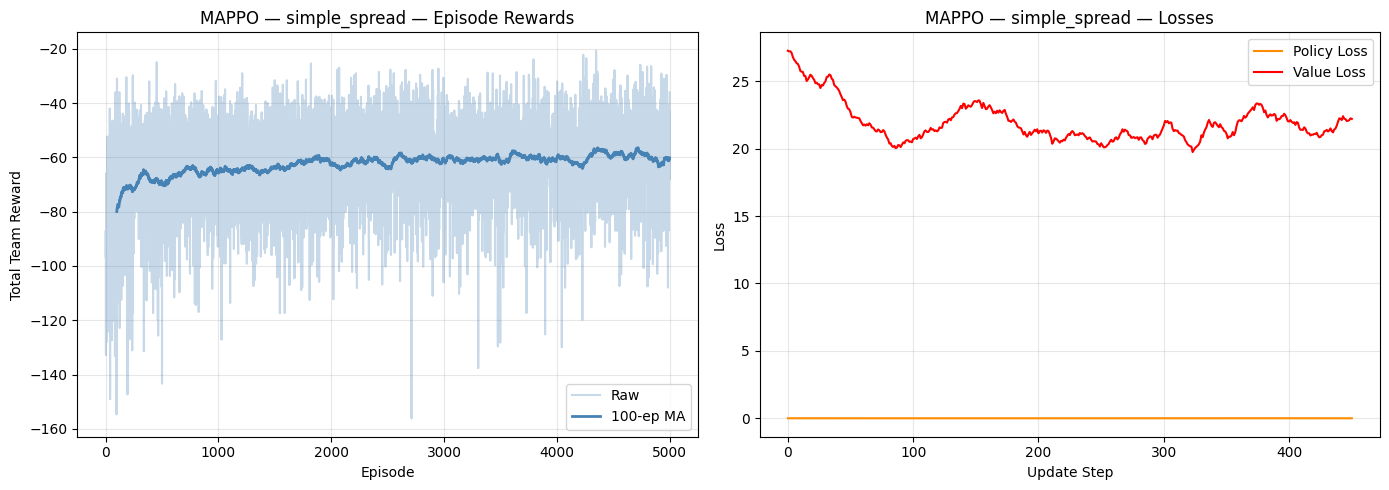

Final avg reward (last 100 ep): -60.2


In [5]:
set_seed(42)

env = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)

mappo_agent = MAPPOAgent(
    obs_dim    = OBS_DIM,
    action_dim = ACTION_DIM,
    n_agents   = N_AGENTS,
    critic     = CentralizedCritic(OBS_DIM, N_AGENTS),
    lr         = 3e-4,
    gamma      = 0.99,
    gae_lambda = 0.95,
    clip_eps   = 0.2,
    vf_coef    = 0.5,
    ent_coef   = 0.001,
    n_epochs   = 4,
    batch_size = 64,
)

results_mappo = train_mappo(env, mappo_agent, n_episodes=5000, rollout_episodes=10,
                            print_every=500)
env.close()

plot_mappo_results(results_mappo, title="MAPPO — simple_spread",
                  window=100, experiments_dir=EXPERIMENTS_DIR)
print(f"Final avg reward (last 100 ep): {np.mean(results_mappo['episode_rewards'][-100:]):.1f}")

### A.2 — MADDPG: Multi-Agent DDPG

MADDPG (Lowe et al., NeurIPS 2017) extends single-agent DDPG to multi-agent settings using CTDE:

**Key differences from MAPPO:**

| | MAPPO | MADDPG |
|---|---|---|
| Policy update | On-policy (PPO clip) | Off-policy (DPG via Gumbel-Softmax) |
| Actor | **Shared** weights across agents | **Independent** per-agent weights |
| Critic | V(o₁…oₙ) — value function | Q_i(o₁…oₙ, a₁…aₙ) — Q-function per agent |
| Data | Episode rollouts | Replay buffer |
| Target nets | ✗ | ✓ Soft-updated (Polyak averaging) |

**Training loop for each gradient step:**
1. **Critic update**: minimize Bellman TD error using target networks  
   `y_i = r_i + γ · Q_i^target(s', π_target(s'))` → MSE loss
2. **Actor update**: maximize `Q_i` via Gumbel-Softmax (differentiable discrete actions)  
   `L_i = −Q_i(s, [a_1^gs, …, a_N^gs])`  where only agent `i`'s action uses gradients
3. **Soft target update**: `θ_target ← τ·θ + (1−τ)·θ_target`

In [ ]:
class MADDPGAgents:
    """
    MADDPG: Multi-Agent DDPG with Centralized Critics (CTDE).

    Each agent i maintains four networks:
      - actor_i:         π_i(a_i | o_i)            local obs  → action probs
      - target_actor_i:  lagged copy of actor_i
      - critic_i:        Q_i(o, a)                 joint obs + joint actions → Q
      - target_critic_i: lagged copy of critic_i

    Off-policy training via a shared MultiAgentReplayBuffer.
    Discrete actions are handled via Gumbel-Softmax during policy gradient.

    CTDE principle:
      - EXECUTION : each agent acts from its OWN observation only (decentralized)
      - TRAINING  : each agent's critic sees ALL observations and actions (centralized)
    """

    def __init__(
        self,
        obs_dim: int,
        action_dim: int,
        n_agents: int,
        lr_actor: float = 1e-3,
        lr_critic: float = 1e-3,
        gamma: float = 0.99,
        tau: float = 0.005,      # soft target update rate (Polyak averaging)
        batch_size: int = 1024,
        buffer_capacity: int = 1_000_000,
        warmup_steps: int = 1000,
    ):
        self.obs_dim      = obs_dim
        self.action_dim   = action_dim
        self.n_agents     = n_agents
        self.gamma        = gamma
        self.tau          = tau
        self.batch_size   = batch_size
        self.warmup_steps = warmup_steps
        self.total_steps  = 0

        # Per-agent networks (provided — do NOT modify)
        self.actors         = [MADDPGActor(obs_dim, action_dim).to(device) for _ in range(n_agents)]
        self.target_actors  = [MADDPGActor(obs_dim, action_dim).to(device) for _ in range(n_agents)]
        self.critics        = [MADDPGCritic(obs_dim, action_dim, n_agents).to(device) for _ in range(n_agents)]
        self.target_critics = [MADDPGCritic(obs_dim, action_dim, n_agents).to(device) for _ in range(n_agents)]

        # Initialise target networks as exact copies
        for i in range(n_agents):
            self.target_actors[i].load_state_dict(self.actors[i].state_dict())
            self.target_critics[i].load_state_dict(self.critics[i].state_dict())

        self.actor_optims  = [torch.optim.Adam(self.actors[i].parameters(),  lr=lr_actor)  for i in range(n_agents)]
        self.critic_optims = [torch.optim.Adam(self.critics[i].parameters(), lr=lr_critic) for i in range(n_agents)]

        self.buffer = MultiAgentReplayBuffer(buffer_capacity, obs_dim, action_dim, n_agents)

    @torch.no_grad()
    def select_actions(self, obs_dict: dict, agent_list: list, explore: bool = True):
        """
        Select actions for all agents — DECENTRALIZED execution.
        Each agent uses only its OWN observation and its OWN actor.

        Args:
            obs_dict   (dict): {agent_id: np.array(obs_dim)}
            agent_list (list): ordered agent ids
            explore    (bool): sample if True, argmax if False

        Returns:
            actions    (dict): {agent_id: int}
            actions_oh (dict): {agent_id: np.array(action_dim)}  one-hot
        """
        # TODO: For each agent, pass its own observation through its own actor
        # to get a discrete action and a one-hot encoding of that action.
        i = 0
        actions, actions_oh = {}, {}
        for agent in agent_list:
            #Get action
            obs_t = torch.tensor(obs_dict[agent], dtype=torch.float32).to(device).unsqueeze(0)
            action, action_oh = self.actors[i].get_action(obs_t, explore)
            
            #Put into dicts with correct format
            actions[agent] = action.item()
            actions_oh[agent] = action_oh.squeeze(0).cpu().numpy()
            i += 1
            
        return actions, actions_oh
            

    def update(self):
        """
        One gradient update step for all N agents.

        Returns (None, None) if the replay buffer has fewer than batch_size transitions.

        For each agent i:
          1. Critic update: compute the Bellman TD target using the target networks
             (target actors for next actions, target critic for bootstrap value),
             then minimize MSE between the current critic and the target.
          2. Actor update: maximize Q_i by passing agent i's action through
             Gumbel-Softmax (keeping other agents' actions from the buffer),
             so gradients flow through the discrete action.
          3. Soft-update target networks for both actors and critics.

        Returns:
            (mean_actor_loss, mean_critic_loss) across N agents
        """
        if len(self.buffer) < self.batch_size:
            return None, None

        # TODO: Implement the MADDPG update step.
        #Sample from buffer and send to device
        obs, actions, rewards, next_obs, dones = self.buffer.sample(self.batch_size)
        obs = obs.to(device)            #(batch, n_agents, obs_dim)
        actions = actions.to(device)    #(batch, n_agents, action_dim). All action variables in this method one-hot encoded!!
        rewards = rewards.to(device)    #(batch, n_agents)
        next_obs = next_obs.to(device)  #(batch, n_agents, obs_dim)
        dones = dones.to(device)        #(batch,)
        
        #Flatten agent dim since critic expects that
        joint_obs = obs.reshape(self.batch_size, -1)            #(batch, n_agents*obs_dim)
        joint_next_obs = next_obs.reshape(self.batch_size, -1)  #(batch, n_agents*obs_dim)
        joint_actions = actions.reshape(self.batch_size, -1)    #(batch, n_agents*action_dim)
        
        #Track actor and critic losses
        critic_losses, actor_losses = [], []
        
        for i in range(self.n_agents):
            #STEP 1: CRITIC UPDATE ----------------------------
            
            #No gradient tracking on target networks
            with torch.no_grad():
                next_actions = []
                for j in range(self.n_agents):
                    #Get next one-hot actions from all target actors
                    _, next_action = self.target_actors[j].get_action(next_obs[:, j, :], explore=False)
                    next_actions.append(next_action)
                    
                next_actions = torch.cat(next_actions, dim=-1) #(batch, n_agents*action_dim)
                
                #Bootstrap target value using target critic
                y = rewards[:, i] + self.gamma * self.target_critics[i](joint_next_obs, next_actions).squeeze(-1) * (1 - dones)
                
            #Critic's current Q estimate
            Q_i = self.critics[i](joint_obs, joint_actions).squeeze(-1)
            
            #MSE between Q and TD target
            critic_loss = F.mse_loss(Q_i, y)
            critic_losses.append(critic_loss.item()) #track lossses
            
            #Critic's gradient update
            self.critic_optims[i].zero_grad()
            critic_loss.backward()
            self.critic_optims[i].step()
            
            #STEP 2: ACTOR UPDATE ------------------------------
            actions_gs_at_i = []
            for j in range(self.n_agents):
                if j == i:
                    actions_gs_at_i.append(self.actors[i].gumbel_softmax_action(obs[:, i, :]))
                else:
                    actions_gs_at_i.append(actions[:, j, :])
            actions_gs_at_i = torch.cat(actions_gs_at_i, dim=-1) #(batch, n_agents*action_dim)
            
            #Maximize Q_i, so we need negative to minimize loss
            actor_loss = -self.critics[i](joint_obs, actions_gs_at_i).mean()
            actor_losses.append(actor_loss.item()) #track losses
            
            #Actor's gradient update
            self.actor_optims[i].zero_grad()
            actor_loss.backward()
            self.actor_optims[i].step()
            
            #STEP 3: SOFT TARGET UPDATE ----------------------------
            with torch.no_grad():
                #Update target networks according to formula in README
                for param, target_param in zip(self.actors[i].parameters(), self.target_actors[i].parameters()):
                    target_param.copy_(self.tau * param + (1.0 - self.tau) * target_param)
                
                for param, target_param in zip(self.critics[i].parameters(), self.target_critics[i].parameters()):
                    target_param.copy_(self.tau * param + (1.0 - self.tau) * target_param)
                    
        return np.mean(actor_losses), np.mean(critic_losses)

In [6]:
def train_maddpg(env, agents, n_episodes=3000, updates_per_step=1, print_every=300):
    """
    Train MADDPGAgents on a PettingZoo parallel environment.

    Fully provided — do NOT modify.

    Off-policy step-by-step collection. Rewards are normalised using a
    running mean/std (Welford online algorithm) before being stored in the
    replay buffer — this stabilises critic targets and prevents Q-value
    divergence.

    Returns:
        results (dict): 'episode_rewards', 'actor_losses', 'critic_losses'
    """
    results = {'episode_rewards': [], 'actor_losses': [], 'critic_losses': []}

    # Running reward statistics for normalisation (Welford online algorithm)
    rew_mean  = np.zeros(agents.n_agents, dtype=np.float64)
    rew_var   = np.ones(agents.n_agents,  dtype=np.float64)
    rew_count = 1e-4

    for episode in range(n_episodes):
        obs_dict, _     = env.reset()
        agent_list      = list(obs_dict.keys())
        ep_total_reward = 0.0

        while env.agents:
            actions, actions_oh = agents.select_actions(obs_dict, agent_list, explore=True)
            agents.total_steps += 1

            next_obs, rewards, terminations, truncations, _ = env.step(actions)
            dones = {a: terminations.get(a, False) or truncations.get(a, False)
                     for a in agent_list}
            done = any(dones.values())

            obs_arr      = np.array([obs_dict[a]         for a in agent_list])
            actions_arr  = np.array([actions_oh[a]       for a in agent_list])
            rewards_arr  = np.array([rewards.get(a, 0.0) for a in agent_list])
            next_obs_arr = np.array([next_obs.get(a, obs_dict[a]) for a in agent_list])

            # Running normalisation of rewards before storing in buffer
            batch_mean = rewards_arr.mean(axis=0)
            rew_count += 1
            delta      = batch_mean - rew_mean
            rew_mean  += delta / rew_count
            rew_var    = rew_var + delta * (batch_mean - rew_mean)
            rew_std    = np.sqrt(rew_var / rew_count + 1e-8)
            rewards_norm = (rewards_arr - rew_mean) / rew_std

            agents.buffer.push(obs_arr, actions_arr, rewards_norm, next_obs_arr, done)
            ep_total_reward += rewards_arr.sum()   # log raw reward

            if agents.total_steps > agents.warmup_steps:
                for _ in range(updates_per_step):
                    a_loss, c_loss = agents.update()
                    if a_loss is not None:
                        results['actor_losses'].append(a_loss)
                        results['critic_losses'].append(c_loss)

            obs_dict = next_obs

        results['episode_rewards'].append(ep_total_reward)

        if (episode + 1) % print_every == 0:
            mean_r = np.mean(results['episode_rewards'][-print_every:])
            print(f"Episode {episode+1:4d} | Mean Team Reward: {mean_r:7.2f} "
                  f"| Buffer: {len(agents.buffer):,}")

    return results

### A.2 — Train MADDPG on simple_spread

Train 3 cooperative agents using off-policy MADDPG.  
Verify your implementation produces a learning curve (reward should improve over training).

Episode  300 | Mean Team Reward:  -85.42 | Buffer: 7,500
Episode  600 | Mean Team Reward:  -72.53 | Buffer: 15,000
Episode  900 | Mean Team Reward:  -66.64 | Buffer: 22,500
Episode 1200 | Mean Team Reward:  -67.62 | Buffer: 30,000
Episode 1500 | Mean Team Reward:  -71.39 | Buffer: 37,500
Episode 1800 | Mean Team Reward:  -70.99 | Buffer: 45,000
Episode 2100 | Mean Team Reward:  -72.11 | Buffer: 52,500
Episode 2400 | Mean Team Reward:  -73.17 | Buffer: 60,000
Episode 2700 | Mean Team Reward:  -67.23 | Buffer: 67,500
Episode 3000 | Mean Team Reward:  -71.26 | Buffer: 75,000
Plot saved → /home/arviv790/Code/LiU/tdde78/labs/lab5_multi_agent/experiments/plots/maddpg__simple_spread.png


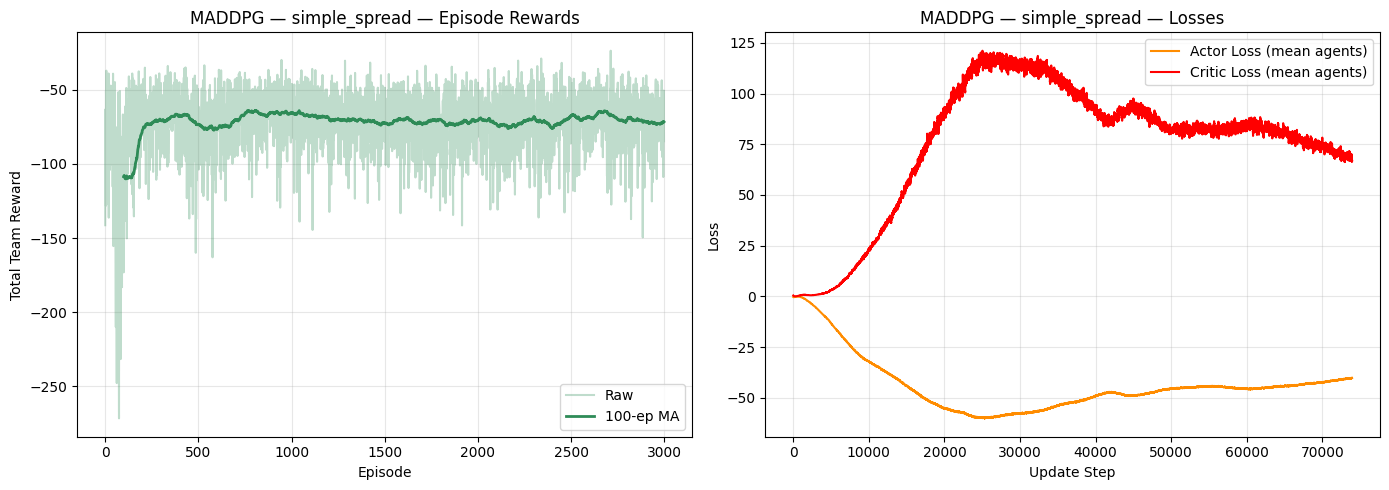

Final avg reward (last 100 ep): -71.5


In [7]:
set_seed(42)

env_maddpg = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)

maddpg_agents = MADDPGAgents(
    obs_dim         = OBS_DIM,
    action_dim      = ACTION_DIM,
    n_agents        = N_AGENTS,
    lr_actor        = 1e-3,
    lr_critic       = 3e-4,   # lower to prevent Q-value divergence
    gamma           = 0.99,
    tau             = 0.005,
    batch_size      = 1024,
    buffer_capacity = 1_000_000,
    warmup_steps    = 1000,
)

results_maddpg = train_maddpg(env_maddpg, maddpg_agents, n_episodes=3000, print_every=300)
env_maddpg.close()

plot_maddpg_results(results_maddpg, title="MADDPG — simple_spread",
                   window=100, experiments_dir=EXPERIMENTS_DIR)
print(f"Final avg reward (last 100 ep): {np.mean(results_maddpg['episode_rewards'][-100:]):.1f}")

## Part B: Experiments

Compare MAPPO and MADDPG across multiple seeds to understand when each approach excels.

### B.1 — MAPPO vs MADDPG

Both algorithms follow CTDE but differ fundamentally in their training paradigm:

| Property | MAPPO | MADDPG |
|----------|-------|--------|
| Sample efficiency | Lower (on-policy, discards data) | Higher (off-policy replay) |
| Coordination mechanism | Parameter sharing (shared actor) | Centralized Q-function per agent |
| Stability | More stable (PPO clipping) | Can be less stable (bootstrapping) |
| Scalability | Better with many agents (shared weights) | Grows linearly with agent count |

Run 3 seeds each to measure mean ± std of team reward.

In [11]:
N_SEEDS      = 3
N_MAPPO_EPS  = 5000
N_MADDPG_EPS = 3000

all_results = {'MAPPO': [], 'MADDPG': []}

for seed in range(N_SEEDS):
    set_seed(seed)

    # ---- MAPPO ----
    env = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)
    ag  = MAPPOAgent(
        obs_dim    = OBS_DIM,
        action_dim = ACTION_DIM,
        n_agents   = N_AGENTS,
        critic     = CentralizedCritic(OBS_DIM, N_AGENTS),
        lr         = 3e-4,
        gamma      = 0.99,
        gae_lambda = 0.95,
        clip_eps   = 0.2,
        vf_coef    = 0.5,
        ent_coef   = 0.001,
        n_epochs   = 4,
        batch_size = 64,
    )
    res_mappo = train_mappo(env, ag, n_episodes=N_MAPPO_EPS, rollout_episodes=10,
                            print_every=N_MAPPO_EPS)
    all_results['MAPPO'].append(res_mappo)
    env.close()
    print(f"[Seed {seed}] MAPPO:  final mean = {np.mean(res_mappo['episode_rewards'][-100:]):.2f}")

    # ---- MADDPG ----
    env = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)
    maddpg = MADDPGAgents(
        obs_dim         = OBS_DIM,
        action_dim      = ACTION_DIM,
        n_agents        = N_AGENTS,
        lr_actor        = 1e-3,
        lr_critic       = 3e-4,
        gamma           = 0.99,
        tau             = 0.005,
        batch_size      = 1024,
        buffer_capacity = 1_000_000,
        warmup_steps    = 1000,
    )
    res_maddpg = train_maddpg(env, maddpg, n_episodes=N_MADDPG_EPS,
                              print_every=N_MADDPG_EPS)
    all_results['MADDPG'].append(res_maddpg)
    env.close()
    print(f"[Seed {seed}] MADDPG: final mean = {np.mean(res_maddpg['episode_rewards'][-100:]):.2f}")

print('\nMean +/- Std (last 100 episodes):')
for name, runs in all_results.items():
    final = [np.mean(r['episode_rewards'][-100:]) for r in runs]
    print(f"  {name}: {np.mean(final):.1f} +/- {np.std(final):.1f}")

Episode  5000 | Mean Team Reward:  -61.25
[Seed 0] MAPPO:  final mean = -58.88
Episode 3000 | Mean Team Reward:  -70.95 | Buffer: 75,000
[Seed 0] MADDPG: final mean = -66.96
Episode  5000 | Mean Team Reward:  -62.18
[Seed 1] MAPPO:  final mean = -58.84
Episode 3000 | Mean Team Reward:  -70.90 | Buffer: 75,000
[Seed 1] MADDPG: final mean = -69.16
Episode  5000 | Mean Team Reward:  -61.33
[Seed 2] MAPPO:  final mean = -58.23
Episode 3000 | Mean Team Reward:  -71.95 | Buffer: 75,000
[Seed 2] MADDPG: final mean = -64.56

Mean +/- Std (last 100 episodes):
  MAPPO: -58.6 +/- 0.3
  MADDPG: -66.9 +/- 1.9


Plot saved → /home/arviv790/Code/LiU/tdde78/labs/lab5_multi_agent/experiments/plots/b.1__mappo_vs_maddpg_on_simple_spread.png


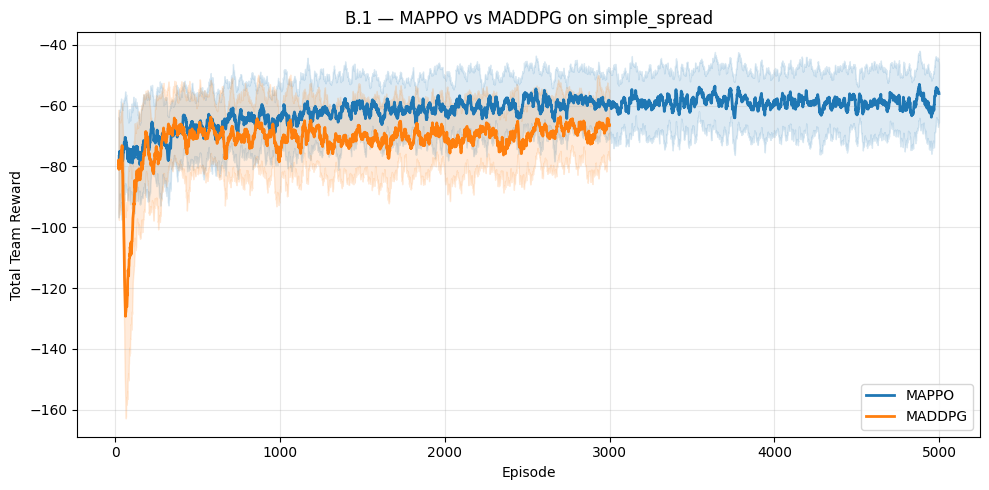

In [12]:
plot_comparison(
    all_results,
    title="B.1 — MAPPO vs MADDPG on simple_spread",
    window=20,
    experiments_dir=EXPERIMENTS_DIR,
)

---

## B.2 — MAPPO: Effect of Entropy Coefficient

The entropy bonus `ent_coef` controls exploration in MAPPO.
Too high → policy stays too random and never converges.
Too low → premature convergence to a suboptimal deterministic policy.

Sweep `ent_coef` ∈ {0.0, 0.001, 0.01, 0.05} over 3 seeds.

Episode  3000 | Mean Team Reward:  -65.51
Episode  3000 | Mean Team Reward:  -62.91
Episode  3000 | Mean Team Reward:  -62.79
Episode  3000 | Mean Team Reward:  -64.23
Episode  3000 | Mean Team Reward:  -62.64
Episode  3000 | Mean Team Reward:  -63.17
Episode  3000 | Mean Team Reward:  -65.10
Episode  3000 | Mean Team Reward:  -64.19
Episode  3000 | Mean Team Reward:  -62.85
Episode  3000 | Mean Team Reward:  -66.14
Episode  3000 | Mean Team Reward:  -65.80
Episode  3000 | Mean Team Reward:  -65.90
Plot saved → /home/arviv790/Code/LiU/tdde78/labs/lab5_multi_agent/experiments/plots/b.2__mappo_entropy_coefficient_ablation.png


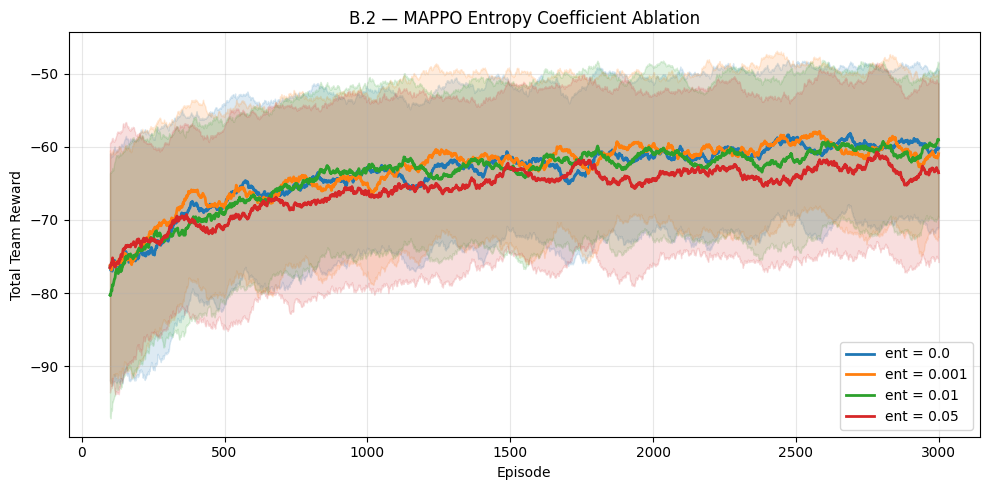

Mean +/- Std (last 100 episodes):
  ent = 0.0: -60.2 +/- 1.4
  ent = 0.001: -60.9 +/- 3.2
  ent = 0.01: -59.0 +/- 1.7
  ent = 0.05: -63.5 +/- 0.7


In [6]:
ent_values = [0.0, 0.001, 0.01, 0.05]
seeds      = [0, 1, 2]

ent_results = {}
for ent in ent_values:
    ent_results[f'ent = {ent}'] = []
    for seed in seeds:
        set_seed(seed)
        env = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)
        ag  = MAPPOAgent(
            obs_dim    = OBS_DIM,
            action_dim = ACTION_DIM,
            n_agents   = N_AGENTS,
            critic     = CentralizedCritic(OBS_DIM, N_AGENTS),
            lr         = 3e-4,
            ent_coef   = ent,
        )
        res = train_mappo(env, ag, n_episodes=3000, print_every=3000)
        ent_results[f'ent = {ent}'].append(res)
        env.close()

plot_comparison(
    ent_results,
    title="B.2 — MAPPO Entropy Coefficient Ablation",
    window=100,
    experiments_dir=EXPERIMENTS_DIR,
)

print('Mean +/- Std (last 100 episodes):')
for name, runs in ent_results.items():
    final = [np.mean(r['episode_rewards'][-100:]) for r in runs]
    print(f'  {name}: {np.mean(final):.1f} +/- {np.std(final):.1f}')

---

## Summary

**TODO:** Write a brief summary of your findings (double-click to edit).

1. **A.1 — MAPPO on simple_spread:** Describe the learning curve. Does the team reward improve? How quickly? What does parameter sharing contribute?

Yes, the team reward does improve until it eventually evens out. We can see in the learning curve that we get ~-80 reward at episode 100 and that the reward increases until episode 1800 where the curve remains stable at ~-60 reward. The convergence is not super fast as it takes almost 2000 episodes, but the training does look stable.

I would say that parameter sharing makes the model more sample-efficient as each gradient update improves all the agents at once, which is an efficient way to use the collected rollout. Parameter sharing seems to work well in simple_spread that is a simple and deterministic environment, and parameter sharing seems to contribute to stable learning here. However, that may not be true in more complex and unpredictable environments where for example agents might have conflicting goals. 


2. **A.2 — MADDPG on simple_spread:** Describe the learning curve. How does convergence compare to MAPPO? Did soft target updates affect stability?

The learning curve here converges at ~750 episodes at around ~-70 team reward, which is faster convergence than MAPPO. This is likely due to that MADDPG is off-policy and uses experiences from the replay buffer, meaning that the agent can learn from past experiences as well. On the other hand, MADDPG converges to a lower value and thus has a worse final performance.

It does seem like the soft target updates did affect stability positively. As we can see in the graph, the critic loss increases a lot in the start, but eventually stabilizes around 75. That the critic loss doesn't diverge here likely is due to that the soft target updates gives the model a stable goal to train for.


3. **B.1 — MAPPO vs MADDPG:** Which algorithm performs better on this cooperative task? Why? Consider on-policy vs off-policy, parameter sharing, and sample efficiency.

MAPPO gave a final average reward of ~-60 while MADDPG had ~-72. Overall MAPPO performs better on this cooperative task as it achieves a higher final reward, making it a stronger choice for this type of cooperative environment. MAPPO does however assume that agents have the same action and observation spaces, so MAPPO wouldn't really function in environments where this isn't the case. In contrast, MADDPG has no limitations regarding this and might work well there with its separate actors and critics for each agent.

MADDPG that is off-policy converges faster thanks to the replay buffer that reuses old experiences. MAPPO that is on-policy reaches a better final performance, which might be because it only uses fresh data from the current policy which in turn gives more correct gradient updates.

Parameter sharing might be beneficial in the simple_spread environment. One gradient update improves the policy for all agents at once, making coordination happen naturally. In MADDPG coordination has to be learned during training for each network independently which likely is more difficult, and may be why it performed worse here in simple_spread.

MADDPG is more sample efficient during training due to the use of the replay buffer. MADDPG converged in ~750 episodes while MAPPO converged in ~1800 episodes which proves this. While MADDPG did have faster convergence, it did however converge to a lower final reward.


4. **B.2 — Entropy coefficient ablation:** Which value works best? What happens at the extremes (0.0 and 0.05)? Why does a small entropy bonus help?

Mean +/- Std (last 100 episodes):
<br>ent = 0.0: -60.2 +/- 1.4
<br>ent = 0.001: -60.9 +/- 3.2
<br>ent = 0.01: -59.0 +/- 1.7
<br>ent = 0.05: -63.5 +/- 0.7

The entropy value that worked best was ent = 0.01. With stochastic methods like MAPPO entropy generally makes the model explore more and try other ways of reaching the goal, which usually results in better performance. Having zero entropy might make the agent stick to a policy with limited knowledge of the environment, which may reduce performance. On the other hand, having too much entropy might make the model explore too much and not commit to what it has already learned, which also can lead to worse performance.

A very small amount of entropy (ent = 0.001) gave similar results to zero entropy (ent = 0.0), but ent = 0.001 may be considered worse because of higher variance which was a bit surprising. Having too much entropy led to the worst performance but it also had the lowest variance, so here the agent has learned a stable but bad policy. The medium value of ent = 0.01 gave the best performance which seems reasonable based on the theoretical reasoning of the last paragraph.

---

**Lab designed by Amath Sow:** [amath.sow@liu.se](mailto:amath.sow@liu.se)

**TDDE78 — Deep Reinforcement Learning, Linköping University — Spring 2026**